# Denoising Autoencoder Implementation using Convolutional NN. The input is MNIST Digits Dataset corrupted with random Gaussian noise

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 279ms/step - loss: 0.2318 - val_loss: 0.1171
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 266ms/step - loss: 0.1149 - val_loss: 0.1089
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 264ms/step - loss: 0.1086 - val_loss: 0.1052
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 266ms/step - loss: 0.1054 - val_loss: 0.1027
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 266ms/step - loss: 0.1036 - val_loss: 0.1013
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


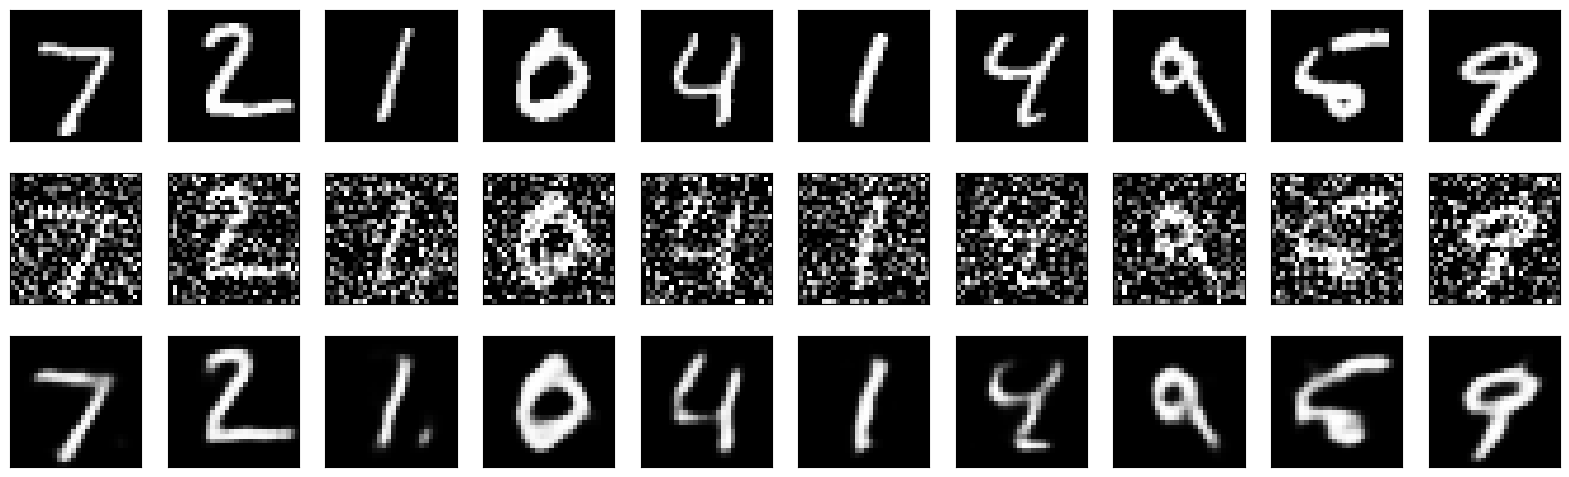

In [2]:
#Example Code: Denoising Autoencoder for Noise Reduction
#This example demonstrates how to use an autoencoder to remove random Gaussian noise from images.
# -----------------------------------------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add noise to the images
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=128, shuffle=True, validation_data=(x_test_noisy, x_test))

# Denoise the images
decoded_imgs = autoencoder.predict(x_test_noisy)

# Display the results with original images
n = 10
plt.figure(figsize=(20, 6))  # Increased height to accommodate 3 rows

for i in range(n):
    # Original images (top row)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy images (middle row)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised images (bottom row)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()